# Cantrol Shadow Hand

In [1]:
import time
import mujoco
import mujoco.viewer
import os.path
import platform
import numpy as np
import mediapy as media
import matplotlib.pyplot as plt
from IPython.display import clear_output
clear_output()

## Load Model

In [55]:
#insert path to your project here
directory = "C:\\Users\mirke\Dash\MuJoCo\mujoco_menagerie-main"
hand = "shadow_hand"
left_or_right = "left"
if left_or_right[0] == 'l' or left_or_right[0] == 'L':
    left_or_right = "scene_left_torque.xml"
else:
    left_or_right = "right_hand.xml"

if platform.system() == "Linux":

     m = mujoco.MjModel.from_xml_path(directory + '/'+hand+'/'+left_or_right)

elif platform.system() == "Windows":

    m = mujoco.MjModel.from_xml_path(directory + '\\'+hand+'\\'+left_or_right)

else:
    print("We don't respect Mac'")


d = mujoco.MjData(m)

#model info
nDOF = m.nv

#define Finger Tips
fingerTips = [m.body('lh_thdistal').id,m.body('lh_ffdistal').id,m.body('lh_mfdistal').id,m.body('lh_rfdistal').id,m.body('lh_lfdistal').id]
#actuatedJoints = [m.jnt('lh_FFJ0').id,m.jnt('lh_FFJ3').id,m.jnt('lh_FFJ4').id,m.jnt('lh_LFJ0').id,m.jnt('lh_LFJ3').id,m.jnt('lh_LFJ4').id,m.jnt('lh_LFJ5').id,m.jnt('lh_MFJ0').id,
                 # m.jnt('lh_MFJ3').id,m.jnt('lh_MFJ4').id,m.jnt('lh_RFJ0').id,m.jnt('lh_RFJ3').id,m.jnt('lh_RFJ4').id,m.jnt('lh_THJ1').id,
                  #m.jnt('lh_THJ2').id,m.jnt('lh_THJ3').id,m.jnt('lh_THJ4').id,m.jnt('lh_THJ5').id,m.jnt('lh_WRJ1').id,m.jnt('lh_WRJ2').id]

In [3]:
#numpy.sort(actuatedJoints)

### Utility

In [ ]:
def quat2SO3(R,quat):
    # was to dumb to use the mujoco.mju_quat2Mat() implementation
    # however this should work to just a bit less efficient
    R[0,0] = 1-2*(quat[2]*quat[2]+quat[3]*quat[3]) 
    R[1,1] = 1-2*(quat[1]*quat[1]+quat[3]*quat[3]) 
    R[2,2] = 1-2*(quat[1]*quat[1]+quat[2]*quat[2]) 
    R[0,1] = 2*(quat[1]*quat[2]-quat[0]*quat[3])
    R[0,2] = 2*(quat[1]*quat[3]+quat[0]*quat[2])
    R[1,0] = 2*(quat[1]*quat[2]+quat[0]*quat[3])
    R[1,2] = 2*(quat[2]*quat[3]-quat[0]*quat[1])
    R[2,0] = 2*(quat[1]*quat[3]-quat[0]*quat[2])
    R[2,1] = 2*(quat[2]*quat[3]+quat[0]*quat[1])

## Coupling Matrix
A = np.zeros([20,30])
A[0,0] = 1
A[1,1] = 1
A[2,19] = 1
A[3,20] = 1
A[4,21] = 1
A[5,22] = 1
A[6,23] = 1
A[7,2] = 1
A[8,3] = 1
A[9,4] = 1
A[9,5] = 1
A[10,6] = 1
A[11,7] = 1
A[12,8] = 1
A[12,9] = 1
A[13,10] = 1
A[14,11] = 1
A[15,12] = 1
A[15,13] = 1
A[16,14] = 1
A[17,15] = 1
A[18,16] = 1
A[19,17] = 1
A[19,18] = 1


In [18]:
## Input

#Pregrasp position
def find_pregrasp(ObjectName):
    x_des[0,0:3] = d.xpos[m.body(ObjectName).id]+np.array([-0.1,0,0.05])
    x_des[1,0:3] = d.xpos[m.body(ObjectName).id]+np.array([0.1,-0.15,0.05])
    x_des[2,0:3] = d.xpos[m.body(ObjectName).id]+np.array([0.1,-0.05,0.05])
    x_des[3,0:3] = d.xpos[m.body(ObjectName).id]+np.array([0.1,0,0.05])
    x_des[4,0:3] = d.xpos[m.body(ObjectName).id]+np.array([0.1,0.1,0.05])

    return x_des

#controller
P_trans = np.array([[100,0,0],[0,100,0],[0,0,100]])
D_trans = np.array([[5,0,0],[0,5,0],[0,0,5]]) #TODO: If time implement damping design

P_rot = np.array([[0,0,0],[0,0,0],[0,0,0]])
D_rot = np.array([[0,0,0],[0,0,0],[0,0,0]]) #TODO: If time implement damping design

def impedanceModel(x_des,P_trans,D_trans,P_rot,D_rot,m,d,J_t,J_r,R_tip,x_err,vel,fingerTips,A):
    x_err = x_des-d.xpos[fingerTips]

    f_des = np.zeros([5,3])
    tau_des = np.zeros(d.ctrl.shape)
    
    for i in range(0,5):
        vel[i] = np.einsum('ij,j',J_t[i],d.qvel)
        #f_des[i,:] = np.einsum('ij,j',R_tip[i]*P_trans*R_tip[i].transpose(),x_err[i,:])-np.einsum('ij,j',R_tip[i]*D_trans*R_tip[i].transpose(),vel[i])
        f_des[i,:] = np.einsum('ij,j',P_trans,x_err[i,:])-np.einsum('ij,j',D_trans.transpose(),vel[i])
        tau_i = np.einsum('ij,j',J_t[i].transpose(),f_des[i,:])
        tau_des = tau_des + np.einsum('ij,j',A,tau_i)

    ##TODO: angles and angular velocities 
    ##TODO: map Wrenches back onto joint space

    return tau_des

def desired_grasp_forces(F_g_obj, jacobian, friction_coeff, obj_pos, fingers_pos):
    r = []
    twists = []
    twist_obj = np.array([[0],
                          [0],
                          [0],
                          [0],
                          [0],
                          [F_g_obj]])
    tau = []
    
    for i in range(len(fingers_pos)):
        r_ci = np.sqrt((fingers_pos[0] - obj_pos[0])**2 + (fingers_pos[1] - obj_pos[1])**2 + (fingers_pos[2] - obj_pos[2])**2)
        r.append(r_ci)
        #need to redo angle y!!!!!!!!!!!!!!!!!!
        angle_y = -(np.pi/2 - np.arcsin((fingers_pos[1] - obj_pos[1])/(fingers_pos[0] - obj_pos[0])))
        angle_z = ( np.arctan((fingers_pos[2] - obj_pos[2])/np.sqrt((fingers_pos[0] - obj_pos[0])**2 + (fingers_pos[1] - obj_pos[1])**2)))
    
        # assume x axis always points to obj center
        rot_y = np.array([[np.cos(angle_y), 0,  np.sin(angle_y)],
                          [0,                              1, 0],
                          [-np.sin(angle_y), 0, np.cos(angle_y)]])
        rot_z = np.array([[1,                              0, 0],
                          [0, np.cos(angle_z),  np.sin(angle_z)],
                          [0, -np.sin(angle_z), np.cos(angle_z)]])
        R_s_ci = rot_y @ rot_z
        R_s_ci_stack = np.vstack(np.hstack(R_s_ci, np.zeros((3,3))),np.hstack(np.zeros(3,3),R_s_ci))
    
        S_r_ci = r_ci* np.array([[0, -(fingers_pos[2] - obj_pos[2]), (fingers_pos[1] - obj_pos[1])],
                                 [(fingers_pos[2] - obj_pos[2]), 0, -(fingers_pos[0] - obj_pos[0])],
                                 [-(fingers_pos[1] - obj_pos[1]), (fingers_pos[0] - obj_pos[0]), 0]])
        P_i = np.vstack(np.hstack(np.eye(3), np.zeros((3,3))),np.hstack(S_r_ci,np.eye(3)))
        B = np.array([[1, 0, 0, 0, 0, 0],
                      [0, 1, 0, 0, 0, 0],
                      [0, 0, 1, 0, 0, 0]])
        G_i = B @ R_s_ci_stack.T @ P_i.T
        
        twist_contact_i = G_i @ twist_obj
        twists.append(twist_contact_i)
        
        rot_y_pi_half = np.array([[ 0, 0,  1],
                                  [ 0, 1,  0],
                                  [-1, 0,  0]])
        #assume, since we only turn contact coordinate system on y and z, that we just have to turn in pi/2 direction for y to get the correct force direction
        f_grasp_i_min =  friction_coeff * rot_y_pi_half @ twist_contact_i[3:]
        #f_i.append(f_grasp_i_min)
        tau_i = - jacobian @ np.array[[[0],[0],[0],[f_grasp_i_min[0]],[f_grasp_i_min[1]],[f_grasp_i_min[2]]]]
        tau.append(tau_i)
    return tau

    
# Actuator signal
#d.ctrl[18] =1.5

In [6]:
d.actuator('lh_A_FFJ0')

<_MjDataActuatorViews
  ctrl: array([0.])
  force: array([0.])
  id: 9
  length: array([0.])
  moment: array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
  name: 'lh_A_FFJ0'
  velocity: array([0.])
>

## Visualisation and Simulation

In [56]:
# reset Data
mujoco.mj_resetData(m, d)

# initial State: Objecet --> spin it realy fast
#d.qvel[27:30] =1*np.random.randn(3)
# visualize contact frames and forces, make body transparent
options = mujoco.MjvOption()
mujoco.mjv_defaultOption(options)
options.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
options.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = False
options.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = False # Object is  set to transparent in rgb value in XML
options.flags[mujoco.mjtFrame.mjFRAME_WORLD] = True

# tweak scales of contact visualization elements
m.vis.scale.contactwidth = 0.3
m.vis.scale.contactheight = 0.02
m.vis.scale.forcewidth = 0.05
m.vis.map.force = 0.03


#Simulation Settings
n_steps_pregrasp = 400
n_steps_softgrasp = 400
n_steps_pinchlift = 2000
n_steps = n_steps_pregrasp+n_steps_softgrasp+n_steps_pinchlift
height = 240
width = 320
frames = []
fps = 60
#WarmUp_Time = 0.2 # stepping into the simulation a couple times so the R matrices don't get initialized with NONE

#Initializations
sim_time = np.zeros(n_steps)
COM_recorded = np.zeros([n_steps,3])
x_smallFinger = np.zeros([n_steps,3])
x_ringFinger = np.zeros([n_steps,3])
x_middleFinger = np.zeros([n_steps,3])
x_foreFinger = np.zeros([n_steps,3])
#see_quats = np.zeros([n_steps,4])
x_thumb = np.zeros([n_steps,3])
x_des = np.zeros([5,3])+d.xpos[m.body('object').id]
jac_t = [np.zeros([3, nDOF]),np.zeros([3, nDOF]),np.zeros([3, nDOF]),np.zeros([3, nDOF]),np.zeros([3, nDOF])] # initialize translation jacobian
jac_r = [np.zeros([3, nDOF]),np.zeros([3, nDOF]),np.zeros([3, nDOF]),np.zeros([3, nDOF]),np.zeros([3, nDOF])] # initialize rotational jacobian
R_Tip = [np.zeros([3,3]),np.zeros([3,3]),np.zeros([3,3]),np.zeros([3,3]),np.zeros([3,3])]
goal = [0.49, 0.13, 0.59]
x_err = np.zeros([n_steps,3])
#x_err = np.zeros([5,3])
vel = [np.einsum('ij,j',jac_t[0],d.qvel),np.einsum('ij,j',jac_t[1],d.qvel),np.einsum('ij,j',jac_t[2],d.qvel),np.einsum('ij,j',jac_t[3],d.qvel),np.einsum('ij,j',jac_t[4],d.qvel)]
# Simulate and display video.


#Perform one initialization Step 
#Step
#mujoco.mj_step(m, d)
#sim_time[0] = d.time

# Kinematics
#mujoco.mj_forward(m, d);
#for i in range(0,4):
#    mujoco.mj_jac(m,d,jac_t[i],jac_r[i],x_des[i],fingerTips[i])
#see_quats[0,:] = d.xquat[fingerTips[4]]
P_trans = np.array([[100,0,0],[0,100,0],[0,0,100]])
D_trans = np.array([[5,0,0],[0,5,0],[0,0,5]]) #TODO: If time implement damping design

P_rot = np.array([[0,0,0],[0,0,0],[0,0,0]])
D_rot = np.array([[0,0,0],[0,0,0],[0,0,0]]) #TODO: If time implement damping design

## Go to grasp/ pre grasp
with mujoco.Renderer(m, height, width) as renderer:
  for i in range(0,n_steps_pregrasp):
    while d.time < i/fps:
        #Step
        mujoco.mj_step(m, d)
        sim_time[i] = d.time

        # Kinematics
        #mujoco.mj_forward(m, d);
        for i in range(0,5):
            mujoco.mj_jac(m,d,jac_t[i],jac_r[i],x_des[i],fingerTips[i])
        quat2SO3(R_Tip[0],d.xquat[fingerTips[0]])
        quat2SO3(R_Tip[1],d.xquat[fingerTips[1]])
        quat2SO3(R_Tip[2],d.xquat[fingerTips[2]])
        quat2SO3(R_Tip[3],d.xquat[fingerTips[3]])
        quat2SO3(R_Tip[4],d.xquat[fingerTips[4]])

        # Controller
        x_des[:,0:3] = find_pregrasp('object')
        #tau_des_grasp = desired_grasp_forces(F_g_obj = None, jacobian = None, friction_coeff = None, obj_pos = None, fingers_pos = None) #replace none with actual values 
        tau_des = impedanceModel(x_des,P_trans,D_trans,P_rot,D_rot,m,d,jac_t,jac_r,R_Tip,x_err,vel,fingerTips,A)
        d.ctrl = tau_des
        # Data for plotting
        COM_recorded[i,:] = d.xpos[m.body('object').id]
        x_smallFinger[i,:] = d.xpos[fingerTips[4]]
        x_ringFinger[i,:] = d.xpos[fingerTips[3]]
        x_middleFinger[i,:]= d.xpos[fingerTips[2]]
        x_foreFinger[i,:] = d.xpos[fingerTips[1]]
        x_thumb[i,:] = d.xpos[fingerTips[0]]


        
        renderer.update_scene(d, "track",options)
        frame = renderer.render()
        frames.append(frame)





## Grasp 
with mujoco.Renderer(m, height, width) as renderer:
  for i in range(0,n_steps_softgrasp):
    while d.time < i/fps:
        #Step
        mujoco.mj_step(m, d)
        sim_time[i] = d.time

        # Kinematics
        #mujoco.mj_forward(m, d);
        for i in range(0,5):
            mujoco.mj_jac(m,d,jac_t[i],jac_r[i],x_des[i],fingerTips[i])
        quat2SO3(R_Tip[0],d.xquat[fingerTips[0]])
        quat2SO3(R_Tip[1],d.xquat[fingerTips[1]])
        quat2SO3(R_Tip[2],d.xquat[fingerTips[2]])
        quat2SO3(R_Tip[3],d.xquat[fingerTips[3]])
        quat2SO3(R_Tip[4],d.xquat[fingerTips[4]])

        # Controller
        x_des[:,0:3] = d.xpos[m.body('object').id]#-np.array([0,0,0.02])
        #tau_des_grasp = desired_grasp_forces(F_g_obj = None, jacobian = None, friction_coeff = None, obj_pos = None, fingers_pos = None) #replace none with actual values 
        tau_des = impedanceModel(x_des,P_trans,D_trans,P_rot,D_rot,m,d,jac_t,jac_r,R_Tip,x_err,vel,fingerTips,A)
        d.ctrl = tau_des
        # Data for plotting
        COM_recorded[i,:] = d.xpos[m.body('object').id]
        x_smallFinger[i,:] = d.xpos[fingerTips[4]]
        x_ringFinger[i,:] = d.xpos[fingerTips[3]]
        x_middleFinger[i,:]= d.xpos[fingerTips[2]]
        x_foreFinger[i,:] = d.xpos[fingerTips[1]]
        x_thumb[i,:] = d.xpos[fingerTips[0]]


        
        renderer.update_scene(d, "track",options)
        frame = renderer.render()
        frames.append(frame)
        

#media.show_video(frames, fps=fps)

## Tighten grasp and lift
# Updating controller
P_trans = np.array([[1500,0,0],[0,1500,0],[0,0,1500]])
D_trans = np.array([[5,0,0],[0,5,0],[0,0,5]]) #TODO: If time implement damping design

P_rot = np.array([[0,0,0],[0,0,0],[0,0,0]])
D_rot = np.array([[0,0,0],[0,0,0],[0,0,0]]) #TODO: If time implement damping design

#P_trans_thumb = np.array([[500,0,0],[0,500,0],[0,0,500]])
#D_trans_thumb = np.array([[5,0,0],[0,5,0],[0,0,5]]) #TODO: If time implement damping design

with mujoco.Renderer(m, height, width) as renderer:
  for i in range(0,n_steps_pinchlift):
    while d.time < i/fps:
        #Step
        mujoco.mj_step(m, d)
        sim_time[i] = d.time

        # Kinematics
        #mujoco.mj_forward(m, d);
        for i in range(0,5):
            mujoco.mj_jac(m,d,jac_t[i],jac_r[i],x_des[i],fingerTips[i])
        quat2SO3(R_Tip[0],d.xquat[fingerTips[0]])
        quat2SO3(R_Tip[1],d.xquat[fingerTips[1]])
        quat2SO3(R_Tip[2],d.xquat[fingerTips[2]])
        quat2SO3(R_Tip[3],d.xquat[fingerTips[3]])
        quat2SO3(R_Tip[4],d.xquat[fingerTips[4]])

        # Controller
        x_des[:,0:3] = d.xpos[m.body('object').id]#+np.array([0,0,0.1])
        #tau_des_grasp = desired_grasp_forces(F_g_obj = None, jacobian = None, friction_coeff = None, obj_pos = None, fingers_pos = None) #replace none with actual values 
        tau_des = impedanceModel(x_des,P_trans,D_trans,P_rot,D_rot,m,d,jac_t,jac_r,R_Tip,x_err,vel,fingerTips,A)
        d.ctrl[0:9] = tau_des [0:9]

        #joint impedance wrist
        P_wrist = 150
        D_wrist = 0
        q_wrist_soll = -0.7
        d.ctrl[1] = P_wrist*(q_wrist_soll-d.jnt('lh_WRJ1').qpos)-D_wrist*d.jnt('lh_WRJ1').qvel
        
        # Data for plotting
        COM_recorded[i,:] = d.xpos[m.body('object').id]
        x_smallFinger[i,:] = d.xpos[fingerTips[4]]
        x_ringFinger[i,:] = d.xpos[fingerTips[3]]
        x_middleFinger[i,:]= d.xpos[fingerTips[2]]
        x_foreFinger[i,:] = d.xpos[fingerTips[1]]
        x_thumb[i,:] = d.xpos[fingerTips[0]]


        
        renderer.update_scene(d, "track",options)
        frame = renderer.render()
        frames.append(frame)
        

media.show_video(frames, fps=fps)

C:\Users\mirke\AppData\Local\Temp\ipykernel_40600\2171212825.py:187: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  d.ctrl[1] = P_wrist*(q_wrist_soll-d.jnt('lh_WRJ1').qpos)-D_wrist*d.jnt('lh_WRJ1').qvel


This browser does not support the video tag.


In [8]:
vel[0]
R_Tip[0].transpose()
d.ctrl

array([ 2.23611778e+01,  1.00000000e+02,  4.57326459e+00, -2.01365087e+00,
       -7.31338060e-01,  2.05670431e+00,  1.95448744e-04, -7.24526338e-01,
        6.44004262e+00,  1.32208373e-01, -9.87416843e-02,  2.96082168e-01,
        9.90183691e-02,  1.58233764e-01,  2.20579845e-01,  7.31845200e-02,
        5.62421485e-01,  1.81959908e-01,  4.04090709e-01,  1.28890053e-01])

In [41]:
m.body('object').pos

array([ 0.32, -0.05, -0.13])

In [49]:
d.xpos[m.body('object').id]
d.jnt('lh_WRJ1').qvel

array([0.04737157])

## Plotting

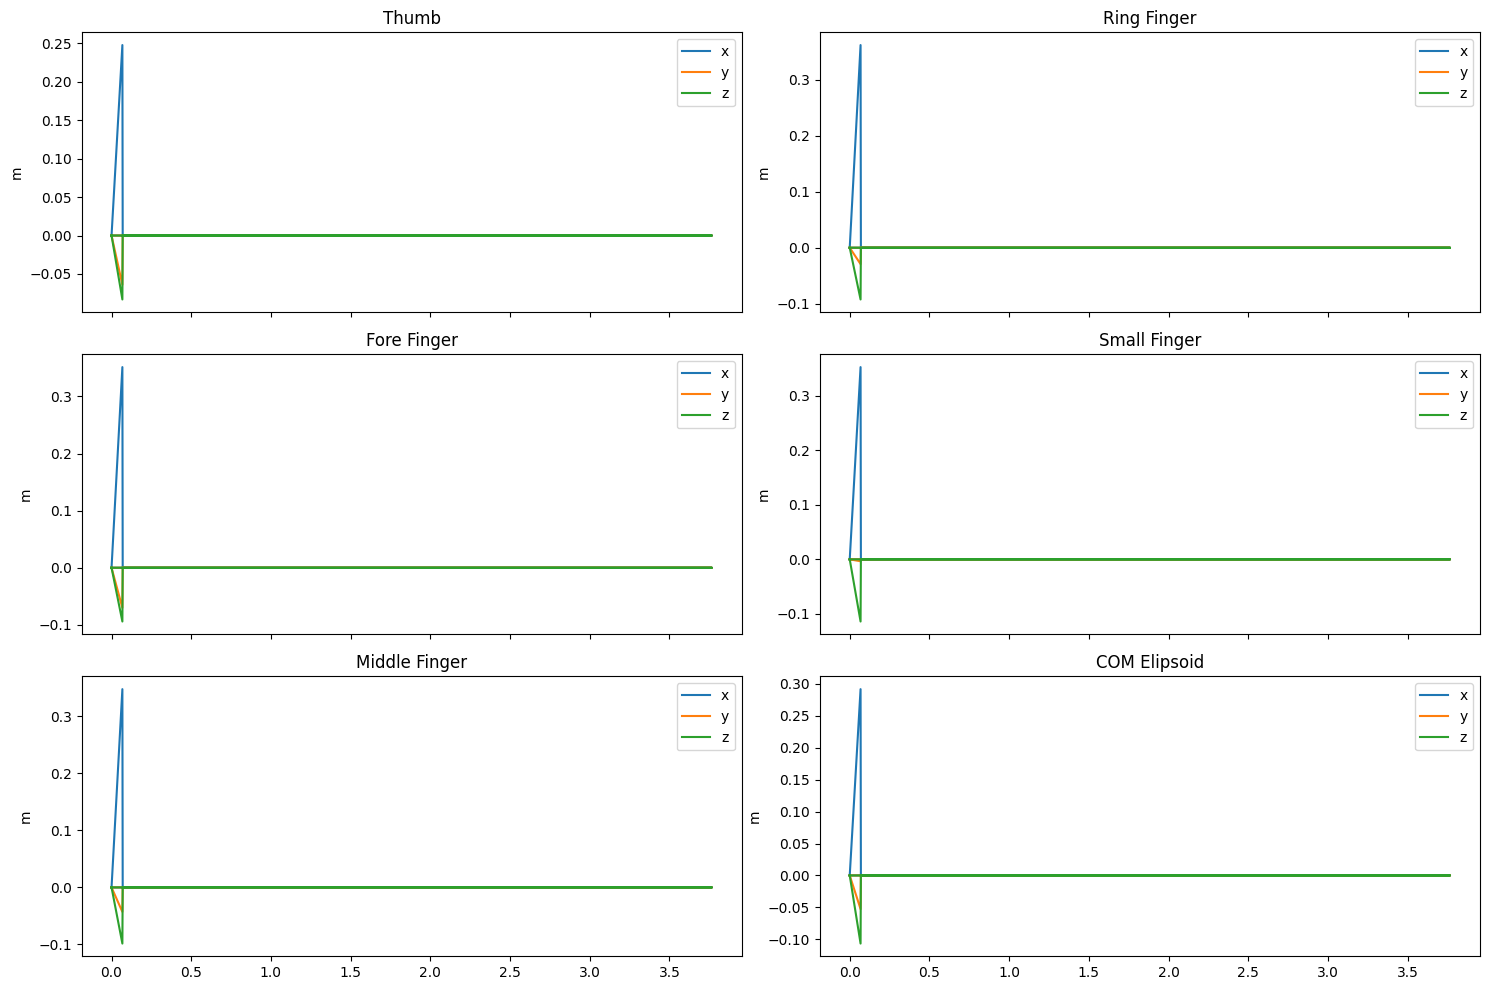

In [10]:
_, ax = plt.subplots(3, 2, sharex=True, figsize=(15, 10))

lines = ax[2,1].plot(sim_time, COM_recorded)
ax[2,1].set_title('COM Elipsoid')
ax[2,1].set_ylabel('m')
ax[2,1].legend(iter(lines), ('x', 'y', 'z'))

lines2 = ax[1,1].plot(sim_time, x_smallFinger)
ax[1,1].set_title('Small Finger')
ax[1,1].set_ylabel('m')
ax[1,1].legend(iter(lines), ('x', 'y', 'z'))

lines3 = ax[0,1].plot(sim_time, x_ringFinger)
ax[0,1].set_title('Ring Finger')
ax[0,1].set_ylabel('m')
ax[0,1].legend(iter(lines), ('x', 'y', 'z'))

lines4 = ax[2,0].plot(sim_time, x_middleFinger)
ax[2,0].set_title('Middle Finger')
ax[2,0].set_ylabel('m')
ax[2,0].legend(iter(lines), ('x', 'y', 'z'))

lines5 = ax[1,0].plot(sim_time, x_foreFinger)
ax[1,0].set_title('Fore Finger')
ax[1,0].set_ylabel('m')
ax[1,0].legend(iter(lines), ('x', 'y', 'z'))

lines6 = ax[0,0].plot(sim_time, x_thumb)
ax[0,0].set_title('Thumb')
ax[0,0].set_ylabel('m')
ax[0,0].legend(iter(lines), ('x', 'y', 'z'))

plt.tight_layout()



In [11]:
#mujoco.mj_jac(m,d,jac_t,jac_r,goal,fingerTips[1])

sorted_names = [];
for i in range(24):
   sorted_names.append( d.jnt(i).name)
sorted_names.append('Myst_DOF6')
sorted_names.append('Myst_DOF5')
sorted_names.append('Myst_DOF4')
sorted_names.append('Myst_DOF3')
sorted_names.append('Myst_DOF2')
sorted_names.append('Myst_DOF1')

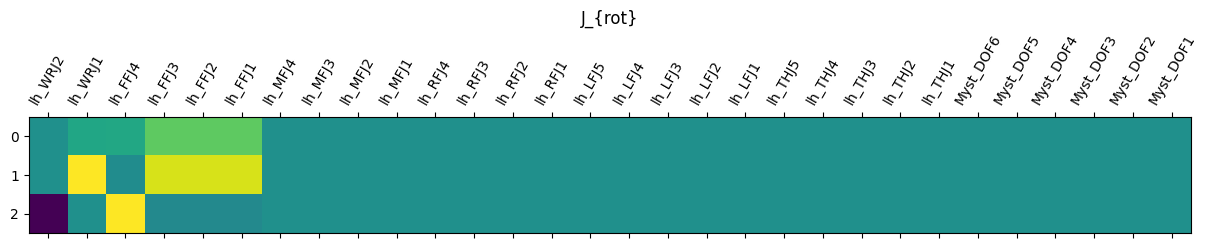

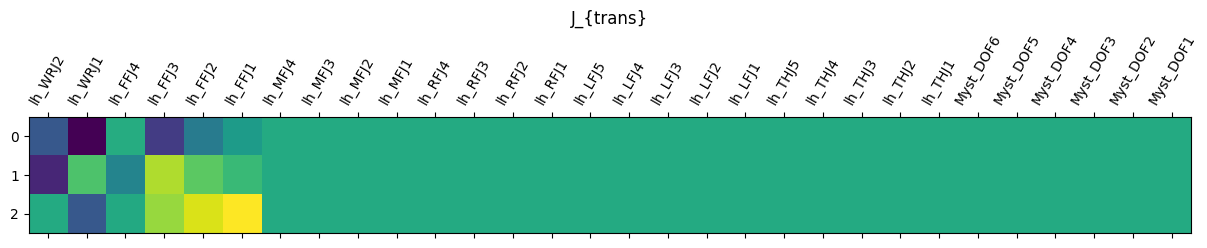

In [12]:
_, ax_jac_r = plt.subplots(1, 1,figsize=(15, 3))
ax_jac_r.matshow(jac_r[1])
ax_jac_r.set_title(r'J_{rot}')
ax_jac_r.set_xticks(range(0,30))
ax_jac_r.set_xticklabels(sorted_names)
ax_jac_r.tick_params(axis='x', labelrotation=60)


_, ax_jac_t = plt.subplots(1, 1,figsize=(15, 3))
ax_jac_t.matshow(jac_t[1])
ax_jac_t.set_title(r'J_{trans}')
ax_jac_t.set_xticks(range(0,30))
ax_jac_t.set_xticklabels(sorted_names)
ax_jac_t.tick_params(axis='x', labelrotation=60)

In [13]:
d.xquat[fingerTips]
test = [d.xquat[fingerTips],d.xquat[fingerTips]]
test[0]
test = np.zeros([5,3])+[1,2,3]#d.xpos[m.body('object').id]
test

array([[1., 2., 3.],
       [1., 2., 3.],
       [1., 2., 3.],
       [1., 2., 3.],
       [1., 2., 3.]])

In [14]:
R_tip = [np.zeros([3,3]),np.zeros([3,3]),np.zeros([3,3]),np.zeros([3,3]),np.zeros([3,3])]
R_tip[0]
test = np.array([1,0,0,0])

In [15]:
R_tip = [mujoco.mju_quat2Mat(R_tip[0].reshape(9,1),test),mujoco.mju_quat2Mat(R_tip[1].reshape(9,1),d.xquat[fingerTips[1]]),mujoco.mju_quat2Mat(R_tip[2].reshape(9,1),d.xquat[fingerTips[2]]),mujoco.mju_quat2Mat(R_tip[3].reshape(9,1),d.xquat[fingerTips[3]]),mujoco.mju_quat2Mat(R_tip[4].reshape(9,1),d.xquat[fingerTips[4]])]

In [16]:

quat2SO3(R_tip[0],test)



TypeError: 'NoneType' object does not support item assignment

### Utility

In [ ]:
A = np.zeros([20,30])
A[0,0] = 1
A[1,1] = 1
A[2,2] = 1
A[3,3] = 1
A[4,4] = 1
A[5,5] = 1
A[6,6] = 1
A[7,7] = 1
A[8,8] = 1
A[9,9] = 1
A[9,10] = 1
A[10,11] = 1
A[11,12] = 1
A[12,13] = 1
A[12,14] = 1
A[13,15] = 1
A[14,16] = 1
A[15,17] = 1
A[15,18] = 1
A[16,19] = 1
A[17,20] = 1
A[18,21] = 1
A[19,22] = 1
A[19,23] = 1

_, ax_A = plt.subplots(1, 1,figsize=(15, 3))
ax_A.matshow(A)